# Import libraries + define paths

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Paths ---
cwd = Path.cwd()
if cwd.name == "notebooks":
    project_root = cwd.parent
elif (cwd / "notebooks").exists():
    project_root = cwd
else:
    project_root = cwd

data_path = project_root / "data" / "processed" / "original_data.csv"
eda_dir = project_root / "results" / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

# Load data

In [9]:
df = pd.read_csv(data_path)

print("Loaded:", data_path.resolve())
print("Shape:", df.shape)
df.head()

Loaded: C:\Users\Lu\OneDrive\ToU\chl_Classification\data\processed\original_data.csv
Shape: (253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


# Define target & check class balance

In [10]:
target_col = "Diabetes_binary"

# Sanity check that it exists
assert target_col in df.columns, f"{target_col} not found in columns!"

# Class balance
counts = df[target_col].value_counts(dropna=False)
proportions = df[target_col].value_counts(normalize=True, dropna=False)

display(counts)
display(proportions.rename("proportion"))

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

Diabetes_binary
0    0.860667
1    0.139333
Name: proportion, dtype: float64

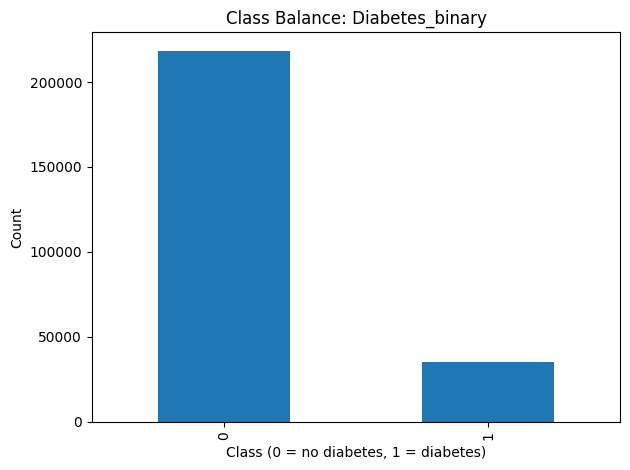

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\eda\class_balance.png


In [11]:
# --- Class balance plot ---
counts = df[target_col].value_counts().sort_index()

plt.figure()
counts.plot(kind="bar")
plt.title("Class Balance: Diabetes_binary")
plt.xlabel("Class (0 = no diabetes, 1 = diabetes)")
plt.ylabel("Count")

out_path = eda_dir / "class_balance.png"
plt.tight_layout()
plt.savefig(out_path, dpi=150)
plt.show()

print("Saved:", out_path.resolve())

**Observations**
- The dataset is **strongly imbalanced**: ~86% class `0` (no diabetes) vs ~14% class `1` (diabetes).
- A naive model could achieve high accuracy by predicting only class `0`, so **accuracy alone is misleading**.

**Implications for next steps**
- Use **stratified train/test split**.
- Prefer metrics suited for imbalance: **F1**, **precision/recall**, **PR-AUC** (and ROC-AUC as a secondary metric).
- Consider **class weights** (and/or threshold tuning) during model training.


# Feature EDA

First, I want to plot the feature vs. target relations. Therefore I need to find out the right plots. Since we have a lot of binary / discrete variables, I seperate continuous variable to the discrete ones:

In [12]:
# --- Identify feature columns ---
feature_cols = [c for c in df.columns if c != target_col]

# --- Numeric features only ---
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Split numeric into discrete vs continuous-ish by unique count
n_unique = df[numeric_cols].nunique().sort_values()
discrete_cols = n_unique[n_unique <= 5].index.tolist()
continuous_cols = n_unique[n_unique > 5].index.tolist()

print("Total features:", len(feature_cols))
print("Numeric features:", len(numeric_cols))
print("Discrete numeric (<=5 unique):", len(discrete_cols))
print("Continuous-ish numeric (>5 unique):", len(continuous_cols))

print("\nDiscrete columns:", discrete_cols)
print("\nContinuous-ish columns:", continuous_cols)


Total features: 21
Numeric features: 21
Discrete numeric (<=5 unique): 15
Continuous-ish numeric (>5 unique): 6

Discrete columns: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'HeartDiseaseorAttack', 'Stroke', 'PhysActivity', 'Fruits', 'NoDocbcCost', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'Sex', 'DiffWalk', 'GenHlth']

Continuous-ish columns: ['Education', 'Income', 'Age', 'MentHlth', 'PhysHlth', 'BMI']


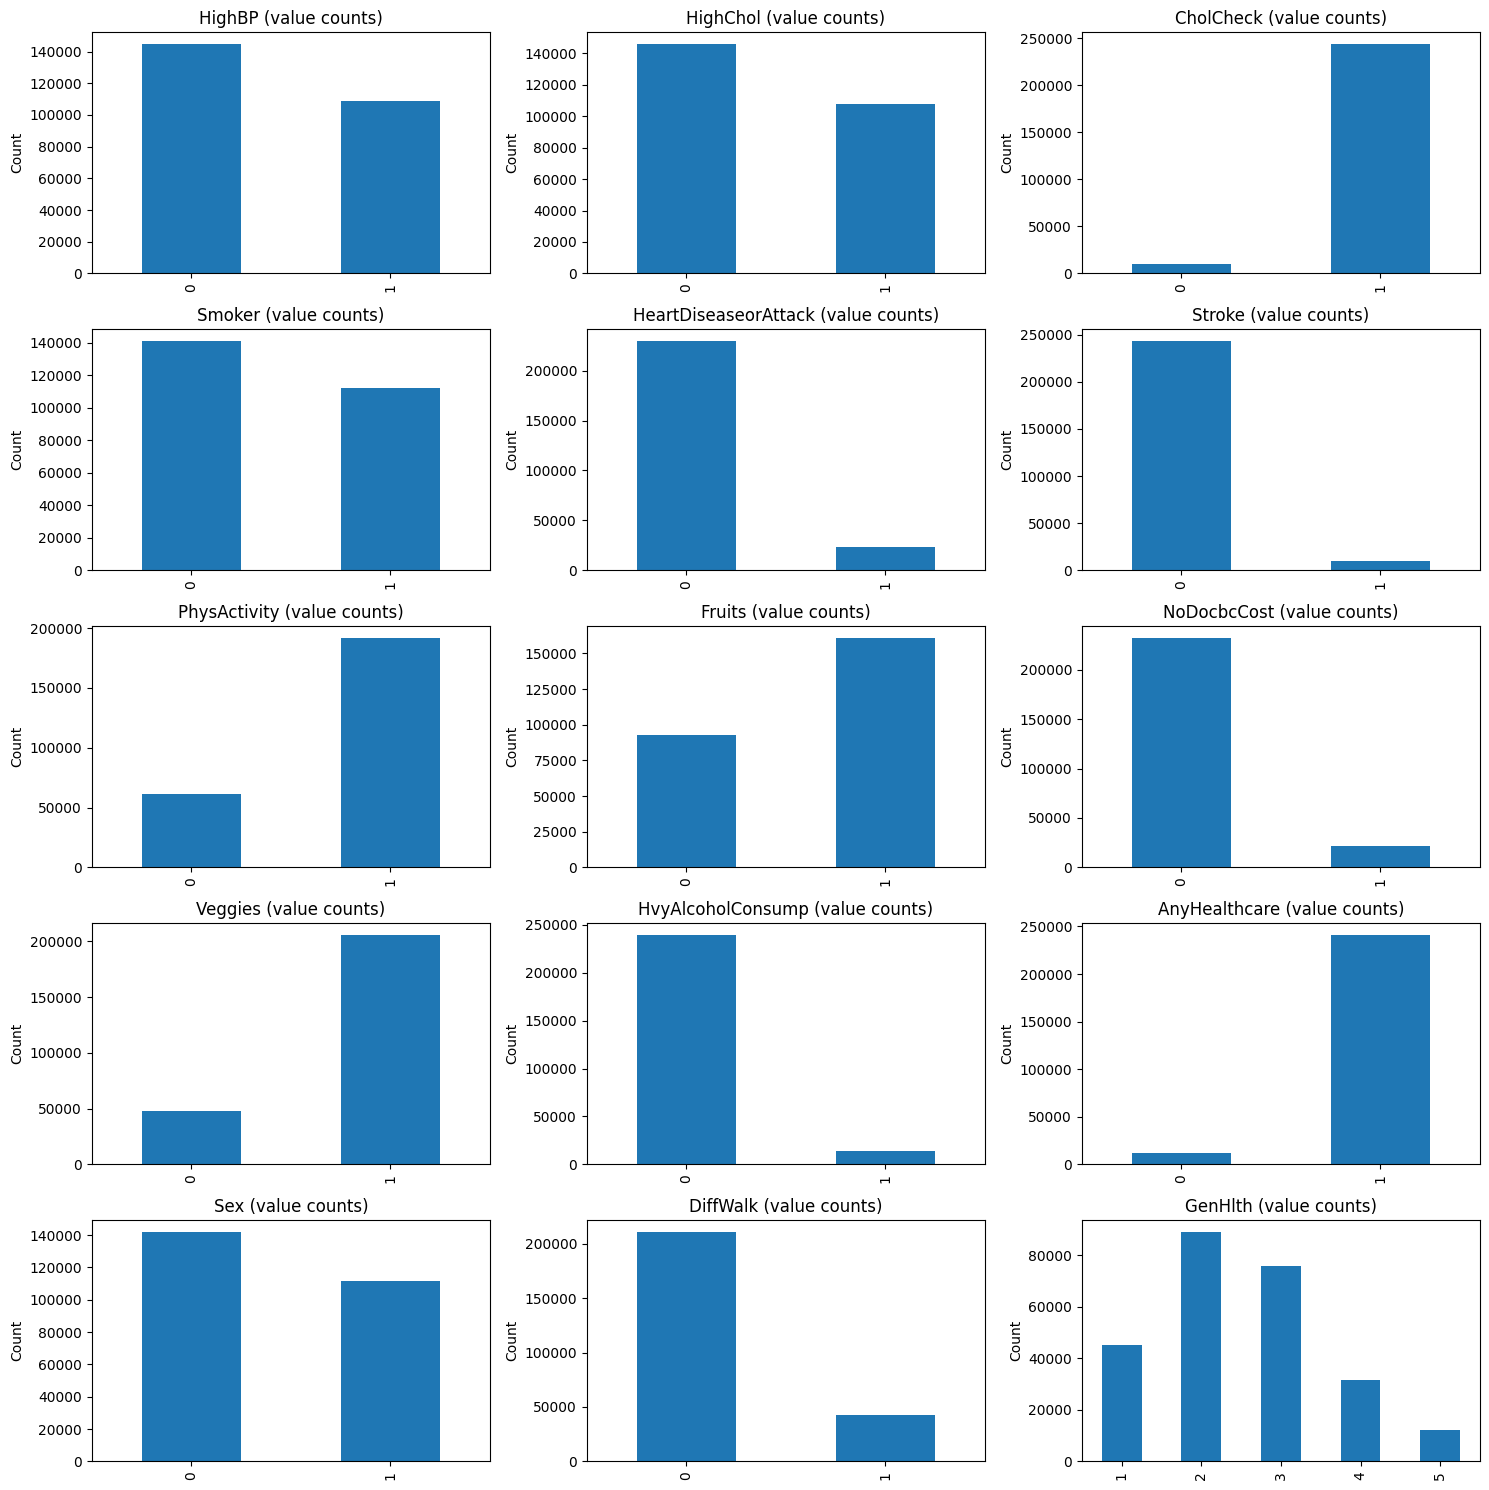

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\eda\univariate_discrete_bars.png


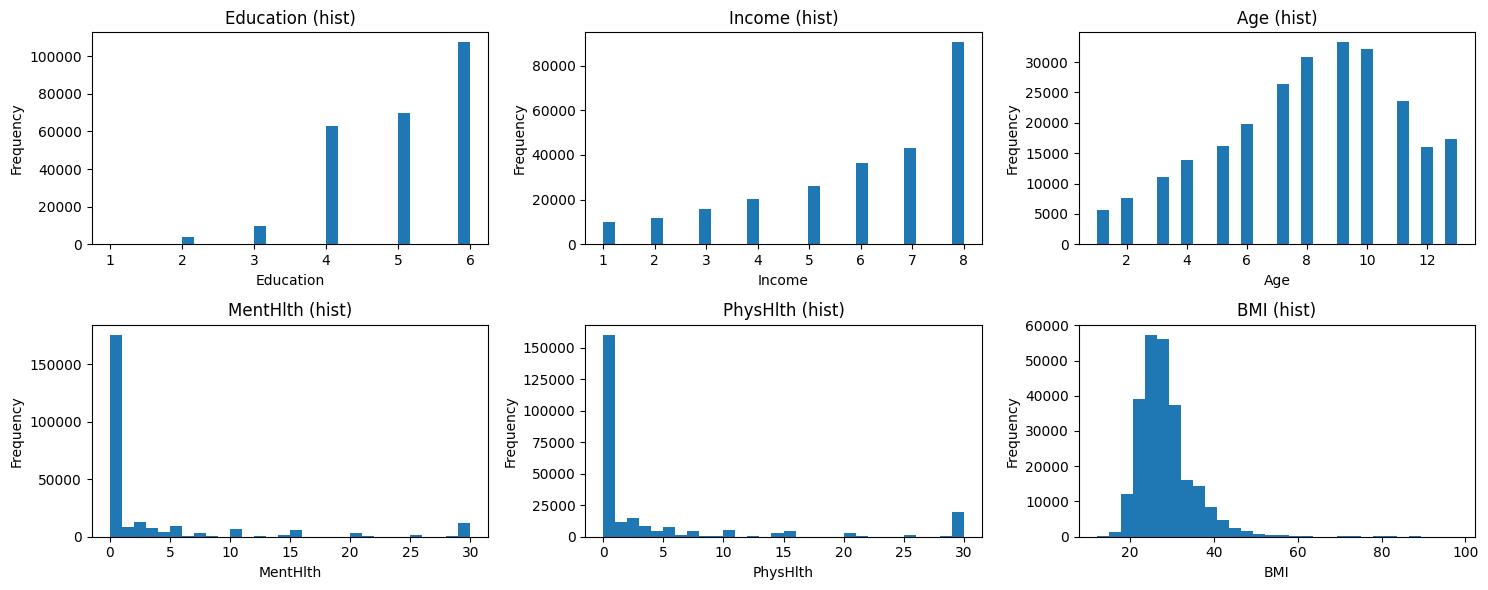

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\eda\univariate_continuous_hists.png


In [13]:
# For discrete variables: bar charts
if len(discrete_cols) > 0:
    n = len(discrete_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*3))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(discrete_cols):
        vc = df[col].value_counts(dropna=False).sort_index()
        vc.plot(kind="bar", ax=axes[i])
        axes[i].set_title(f"{col} (value counts)")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")

    # turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    out_path = eda_dir / "univariate_discrete_bars.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path.resolve())

# For continuous variables: histograms
if len(continuous_cols) > 0:
    n = len(continuous_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*3))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(continuous_cols):
        axes[i].hist(df[col].dropna(), bins=30)
        axes[i].set_title(f"{col} (hist)")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    out_path = eda_dir / "univariate_continuous_hists.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path.resolve())


### Univariate distributions (discrete/binary features)

**Observations**
- Many predictors are **binary/discrete** (e.g., HighBP, HighChol, Smoker, etc.), with **uneven prevalence** in several features.
- Some categories are relatively rare (e.g., Stroke=1), which may introduce noise/variance in learned effects.

**Implications for next steps**
- Keep these as numeric binary/discrete features (no scaling needed for tree models; scaling optional for linear models).
- For rare categories, ensure **stratification** and consider **regularization** (for linear models) to prevent overfitting.


### Univariate distributions (continuous features)

**Observations**
- Several variables (e.g., BMI, MentHlth, PhysHlth) show **skewed distributions** and possible **outliers**.
- MentHlth / PhysHlth appear **zero-inflated** (many zeros) with a long right tail.

**Implications for next steps**
- For linear models: consider **scaling** (StandardScaler) and potentially **robust scaling** if outliers dominate.
- If required, explore simple transformations (e.g., log1p) *only if it improves model performance* (not mandatory).


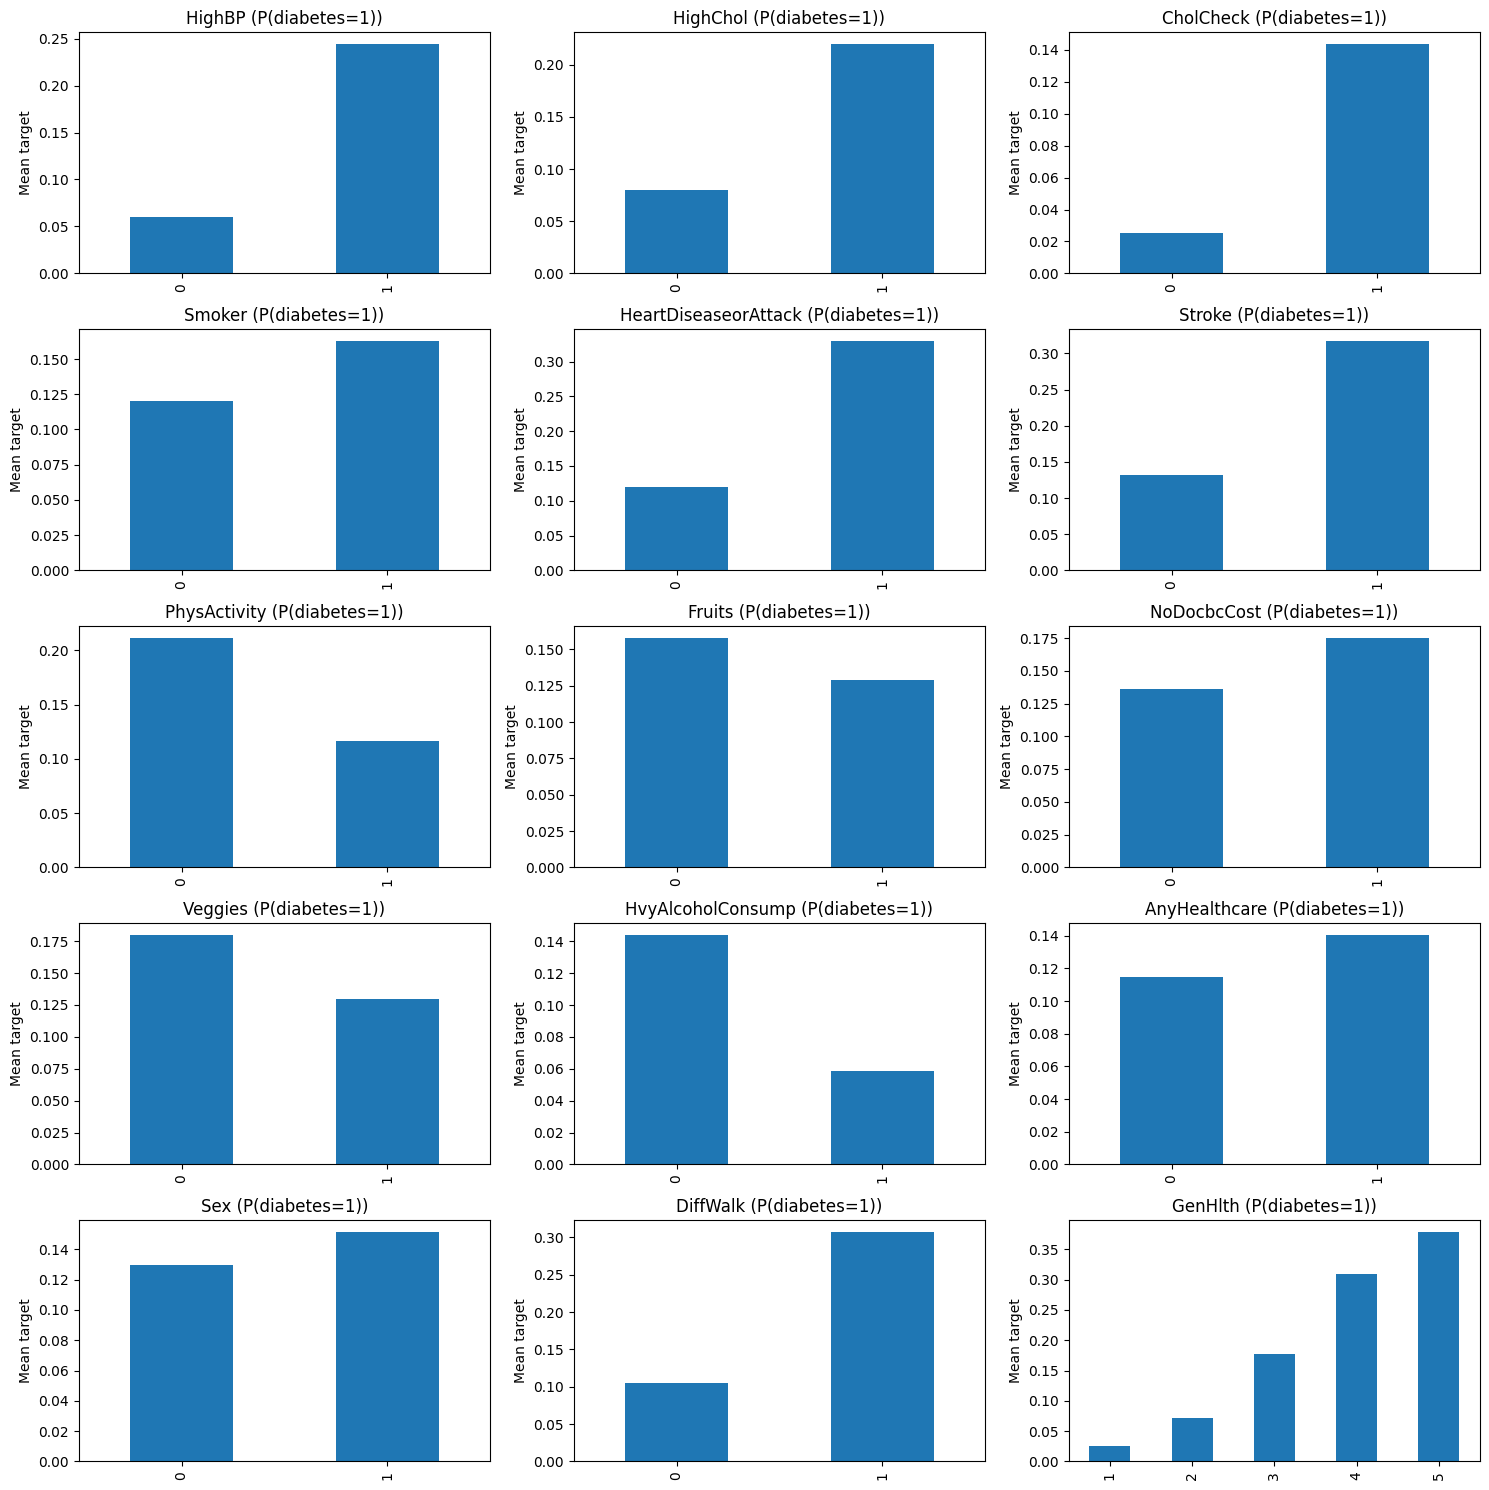

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\eda\bivariate_discrete_diabetes_rate.png


C:\Users\Lu\AppData\Local\Temp\ipykernel_13668\4089100312.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["0", "1"], showfliers=False)
C:\Users\Lu\AppData\Local\Temp\ipykernel_13668\4089100312.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["0", "1"], showfliers=False)
C:\Users\Lu\AppData\Local\Temp\ipykernel_13668\4089100312.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data, labels=["0", "1"], showfliers=False)
C:\Users\Lu\AppData\Local\Temp\ipykernel_13668\4089100312.py:42: MatplotlibDeprecationWarning: The 'labels' paramet

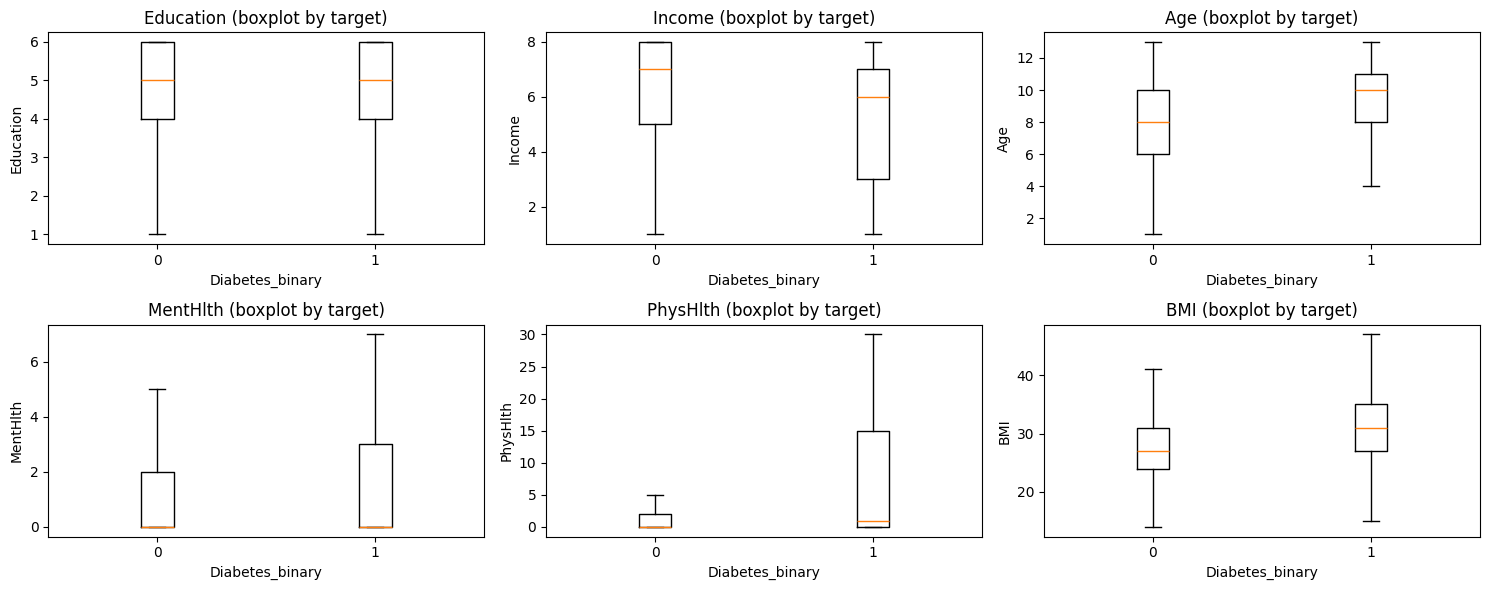

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\eda\bivariate_continuous_boxplots.png


In [14]:
# for discrete variables: diabetes rate by category
if len(discrete_cols) > 0:
    n = len(discrete_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*3))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(discrete_cols):
        rate = df.groupby(col)[target_col].mean()
        rate = rate.sort_index()
        rate.plot(kind="bar", ax=axes[i])
        axes[i].set_title(f"{col} (P(diabetes=1))")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Mean target")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    out_path = eda_dir / "bivariate_discrete_diabetes_rate.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path.resolve())

# for continuous variables: boxplots by target
if len(continuous_cols) > 0:
    n = len(continuous_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*3))
    axes = np.array(axes).reshape(-1)

    # Prepare data split by class for each feature
    df0 = df[df[target_col] == 0]
    df1 = df[df[target_col] == 1]

    for i, col in enumerate(continuous_cols):
        data = [df0[col].dropna().values, df1[col].dropna().values]
        axes[i].boxplot(data, labels=["0", "1"], showfliers=False)
        axes[i].set_title(f"{col} (boxplot by target)")
        axes[i].set_xlabel("Diabetes_binary")
        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    out_path = eda_dir / "bivariate_continuous_boxplots.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path.resolve())


### Discrete features vs target (P(diabetes=1) by category)

**Observations**
- Several binary risk indicators show clear separation in diabetes prevalence:
  - Higher diabetes rate for: **HighBP=1**, **HighChol=1**, **HeartDiseaseorAttack=1**, **Stroke=1**, **DiffWalk=1**, and worse **GenHlth** categories.
- Some lifestyle indicators may show weaker or inverse patterns (e.g., certain activity/diet proxies), which may reflect confounding.

**Implications for next steps**
- These features are likely predictive and should be retained.
- Because relationships may be non-linear and confounded, compare:
  - A **linear baseline** (Logistic Regression) and
  - A **non-linear model** (e.g., RandomForest / XGBoost-like if allowed)
- Use **class weights** or threshold tuning to improve recall for the minority class.


### Continuous-ish features vs target (boxplots by Diabetes_binary)

**Observations**
- Some continuous-ish variables show noticeable shifts between classes:
  - **BMI** tends to be higher for the diabetes class.
  - **Age** tends to be higher for the diabetes class.
  - Health burden proxies (**PhysHlth**, **MentHlth**) may show increased spread and higher values for class `1`.

**Implications for next steps**
- These features likely contribute useful signal.
- Scaling may benefit **Logistic Regression / SVM / KNN**, while tree-based models are less sensitive.
- Outliers exist; for linear models consider robust approaches or regularization.


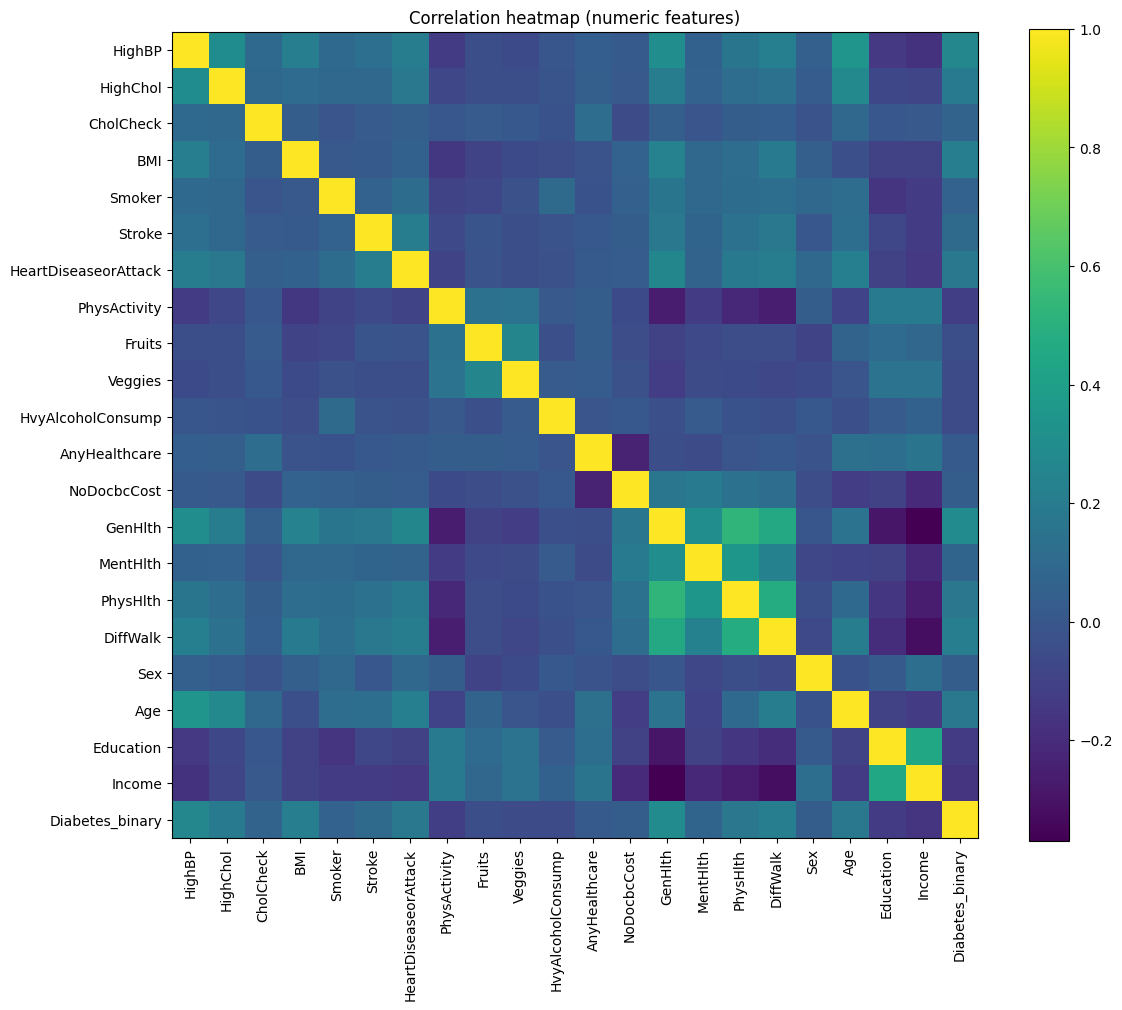

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\eda\correlation_heatmap.png


In [15]:
# Correlation on numeric columns + target
corr_cols = numeric_cols + [target_col] if target_col not in numeric_cols else numeric_cols
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr.values)
plt.title("Correlation heatmap (numeric features)")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.tight_layout()

out_path = eda_dir / "correlation_heatmap.png"
plt.savefig(out_path, dpi=150)
plt.show()

print("Saved:", out_path.resolve())


### Correlation heatmap (numeric features)

**Observations**
- Most pairwise correlations look modest, but there are some **clusters** (e.g., health status measures and difficulty walking).
- `Diabetes_binary` shows positive association with known risk factors (e.g., HighBP, HighChol, BMI, Age, GenHlth-related features), though correlation does not capture non-linear effects.

**Implications for next steps**
- Watch for multicollinearity if using linear models (Logistic Regression):
  - Use **regularization** (L2/L1) to stabilize coefficients.
- Correlation is not the full story → still evaluate non-linear models.


# EDA Summary

This section summarizes the key observations from the exploratory analysis and what they imply for preprocessing and modeling.

---

### 1) Target distribution (class imbalance)

**What we see**
- The dataset is **strongly imbalanced**: ~86% class `0` (no diabetes) vs ~14% class `1` (diabetes).

**What it means for modeling**
- **Accuracy is not sufficient** as a primary metric (a “predict all zeros” model would look good).
- We should use **stratified splits** and focus on **precision/recall**, **F1**, and **PR-AUC** (ROC-AUC as secondary).

---

### 2) Univariate distributions — discrete/binary features

**What we see**
- Many predictors are **binary/discrete** (e.g., HighBP, HighChol, Smoker, etc.).
- Some “1” categories are **rare** (e.g., Stroke=1), meaning limited examples for that group.

**What it means for preprocessing**
- These features can stay as-is (no scaling needed for tree models; scaling optional for linear models).
- Rare categories can increase variance → regularization (for linear models) and careful evaluation are important.

---

### 3) Univariate distributions — continuous-ish features

**What we see**
- Continuous-ish variables (e.g., BMI, MentHlth, PhysHlth, Age/Income/Education) show **skew** and potential **outliers**.
- MentHlth and PhysHlth appear **zero-inflated** (many zeros) with long right tails.

**What it means for preprocessing**
- For linear models, **scaling** (e.g., StandardScaler) will likely help.
- If outliers dominate model performance, we can consider robust scaling or transformations later (only if needed).

---

### 4) Discrete features vs target (P(diabetes=1) by category)

**What we see**
- Clear increases in diabetes prevalence for several risk indicators, such as:
  - **HighBP=1**, **HighChol=1**, **HeartDiseaseorAttack=1**, **Stroke=1**, **DiffWalk=1**
  - Worse **GenHlth** categories tend to correspond to higher diabetes prevalence.

**What it means for modeling**
- These predictors likely carry strong signal.
- Relationships may be non-linear/confounded → compare a **linear baseline** (Logistic Regression) with at least one **non-linear model** (e.g., tree-based).

---

### 5) Continuous-ish features vs target (boxplots by class)

**What we see**
- Separation between classes for several variables:
  - **BMI** tends to be higher for diabetes cases.
  - **Age** tends to be higher for diabetes cases.
  - Health burden proxies (**PhysHlth**, **MentHlth**) show different spreads/levels for class `1`.

**What it means for preprocessing/modeling**
- These features should be retained and are likely important.
- Scaling will matter more for linear/distance-based models than for tree models.

---

### 6) Correlations (numeric features)

**What we see**
- Overall correlations are mostly modest, with a few feature clusters (health status related variables).
- `Diabetes_binary` correlates positively with known risk factors (e.g., HighBP, HighChol, BMI, Age, GenHlth-related features), but correlation won’t capture non-linear effects.

**What it means for modeling**
- For Logistic Regression: use **regularization** to reduce sensitivity to correlated predictors.
- Still evaluate non-linear models, since correlation is not the full story.

---

### Planned next steps (based on EDA)
- Use a **stratified train/test split**.
- Build a preprocessing pipeline:
  - Separate features/target
  - Scaling for continuous-ish numeric features (especially for linear models)
- Train baseline models with imbalance-aware evaluation:
  - Prefer **F1 / Recall / Precision / PR-AUC**
  - Consider **class_weight="balanced"** for baseline Logistic Regression